In [110]:
"""
code to post process VNA measurments. expects .npz files with data made with following structure: 


data_matrices = {
        'positions [cm]': real_positions,
        'freq [MHz]': np.zeros(NUM_FREQ_POINTS),
        'S11': np.zeros((num_measurments, NUM_FREQ_POINTS), dtype=complex),
        'S21': np.zeros((num_measurments, NUM_FREQ_POINTS), dtype=complex),
        'S31': np.zeros((num_measurments, NUM_FREQ_POINTS), dtype=complex),
        'S41': np.zeros((num_measurments, NUM_FREQ_POINTS), dtype=complex)
    } 


The VNA ports are as follows: 

Port 1: Signal port; sending out signal with power P and frequency F to TWA port 1 
Port 2: return from TWA port 2 
Port 3: return from TWA port 3
Port 4: return from the difference port of the Eprobe's 180 degree hybrid difference port  

"""

"\ncode to post process VNA measurments. expects .npz files with data made with following structure: \n\n\ndata_matrices = {\n        'positions [cm]': real_positions,\n        'freq [MHz]': np.zeros(NUM_FREQ_POINTS),\n        'S11': np.zeros((num_measurments, NUM_FREQ_POINTS), dtype=complex),\n        'S21': np.zeros((num_measurments, NUM_FREQ_POINTS), dtype=complex),\n        'S31': np.zeros((num_measurments, NUM_FREQ_POINTS), dtype=complex),\n        'S41': np.zeros((num_measurments, NUM_FREQ_POINTS), dtype=complex)\n    } \n\n\nThe VNA ports are as follows: \n\nPort 1: Signal port; sending out signal with power P and frequency F to TWA port 1 \nPort 2: return from TWA port 2 \nPort 3: return from TWA port 3\nPort 4: return from the difference port of the Eprobe's 180 degree hybrid difference port  \n\n"

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline

In [112]:
# ==========================================
# 1. USER INPUTS
# ==========================================
FILENAME = 'shoe_box_exp_results_data/vna_salt_day_2_96_rez_new_side_smaprobe_5_5cm_gap.npz'

# The specific frequency you want to extract the spatial wave from (in MHz)
TARGET_FFT_FREQ_MHZ = 95

clight = 3e8

In [113]:
# ==========================================
# 2. DYNAMIC DATA UNPACKING
# ==========================================
print(f"Loading {FILENAME}...")
data = np.load(FILENAME)

# Unpack the axes directly from the file!
freqs_mhz = data['freq [MHz]']
positions_cm = data['positions [cm]']

# Unpack the complex S-parameter matrices
S11 = data['S11']
S21 = data['S21']
S31 = data['S31']
S41 = data['S41']

num_measurements = len(positions_cm)

# Dynamically calculate the physical dx step size used in the experiment
dx_real_cm = positions_cm[1] - positions_cm[0]
dx_real_meters = dx_real_cm / 100.0
print(f"Detected spatial step size: {dx_real_cm:.4f} cm")

# Find the column index closest to our target 96 MHz
freq_idx = np.argmin(np.abs(freqs_mhz - TARGET_FFT_FREQ_MHZ))
actual_freq_found = freqs_mhz[freq_idx]
print(f"Extracting spatial data for FFT at {actual_freq_found:.2f} MHz")

max_S41 = 20*np.log10(np.max(np.abs(S41)))
print(f'The maximum S41 is {max_S41} dB')

Loading shoe_box_exp_results_data/vna_salt_day_2_96_rez_new_side_smaprobe_5_5cm_gap.npz...
Detected spatial step size: 0.9975 cm
Extracting spatial data for FFT at 94.95 MHz
The maximum S41 is -33.27345151614406 dB


In [114]:
# ==========================================
# 3. S11, S21, S31 MAGNITUDE PROCESSING (dB)
# ==========================================
# Plot S11 from the very first cart position (Index 0). assumes cart has little impact on S11. 
# Formula: dB = 20 * log10(|S|)

idx = 0#int(S11.shape[0]/2) #0
s11_mag_linear = np.abs(S11[idx, :])
s11_db = 20 * np.log10(s11_mag_linear)

s21_mag_linear = np.abs(S21[idx, :])
s21_db = 20 * np.log10(s21_mag_linear)

s31_mag_linear = np.abs(S31[idx, :])
s31_db = 20 * np.log10(s31_mag_linear)

s41_mag_linear = np.abs(S41[idx, :])
s41_db = 20 * np.log10(s41_mag_linear)

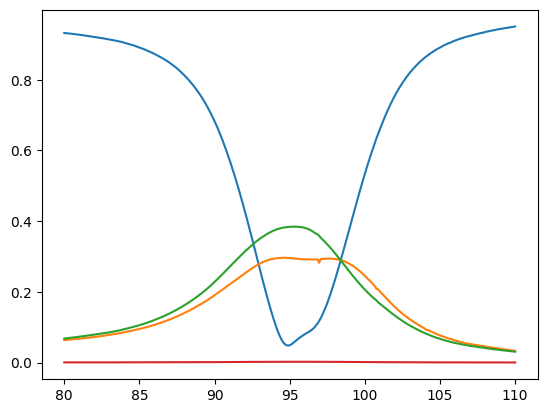

In [115]:
#idx = int(S11.shape[0]/2) #0
plt.plot(freqs_mhz, np.abs(S11[idx,:]))
plt.plot(freqs_mhz, np.abs(S21[idx,:]))
plt.plot(freqs_mhz, np.abs(S31[idx,:]))
plt.plot(freqs_mhz, np.abs(S41[idx,:]))

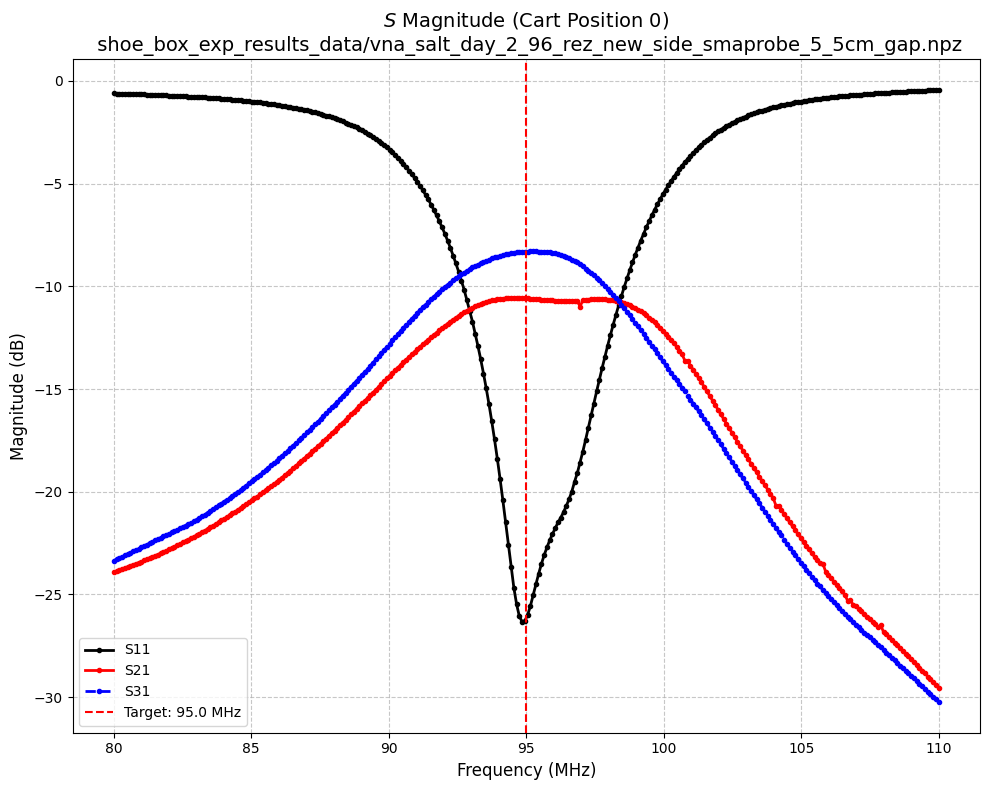

In [116]:
# ==========================================
# PLOTTING Sij
# ==========================================
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
# --- Plot 1: S11, s21, S31 vs Frequency ---
ax.plot(freqs_mhz, s11_db, color='black', marker='.', linewidth=2, label='S11')
ax.plot(freqs_mhz, s21_db, color='red', marker='.', linewidth=2, label='S21')
ax.plot(freqs_mhz, s31_db, color='blue', marker='.', linewidth=2, linestyle='--', label='S31')
#ax.plot(freqs_mhz, s41_db, color='green', marker='.', linewidth=2, linestyle='--', label='S41')

ax.set_title(r'$S$ Magnitude (Cart Position 0)' + f'\n {FILENAME}', fontsize=14)
ax.set_xlabel('Frequency (MHz)', fontsize=12)
ax.set_ylabel('Magnitude (dB)', fontsize=12)
ax.axvline(TARGET_FFT_FREQ_MHZ, color='red', linestyle='--', label=f'Target: {TARGET_FFT_FREQ_MHZ:.1f} MHz')
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

In [117]:
# ==========================================
# 4. S41 SPATIAL FFT PROCESSING (k-space)
# ==========================================
#S41_corrected = S41 / np.sqrt(1 - np.abs(S11)**2)
# Extract the 1D spatial array for just that frequency column
s41_spatial_wave = S41[:, freq_idx]
#s41_spatial_wave = S41_corrected[:, freq_idx]
# --- THE FIX: Define a highly padded length (must be larger than 160, powers of 2 are fastest) ---
PAD_LENGTH = 2048*2

# Perform the Spatial FFT using the padded length
s41_fft = np.fft.fftshift(np.fft.fft(s41_spatial_wave, n=PAD_LENGTH))
s41_fft_mag = np.abs(s41_fft)

# Calculate the wavenumber (k-space) x-axis using the padded length
k_axis = np.fft.fftshift(np.fft.fftfreq(PAD_LENGTH, d=dx_real_meters)) * 2 * np.pi

# Convert to n-space
n_axis = k_axis * clight / (2 * np.pi * actual_freq_found * 1e6)

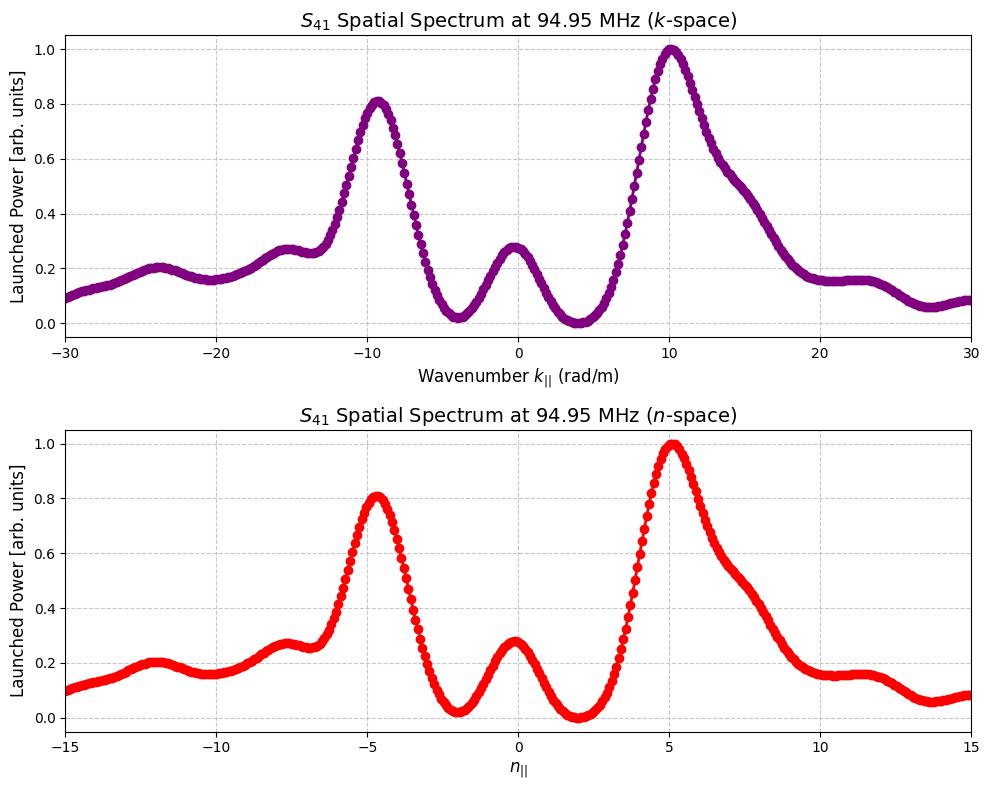

In [118]:
# ==========================================
# PLOTTING FFT
# ==========================================
max_power_spectrum = np.max(s41_fft_mag**2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(k_axis, s41_fft_mag**2/max_power_spectrum, marker='o', color='purple', linewidth=2)
ax1.set_title(r'$S_{41}$ Spatial Spectrum at '+ f'{actual_freq_found:.2f} MHz ($k$-space)', fontsize=14)
ax1.set_xlabel(r'Wavenumber $k_{||}$ (rad/m)', fontsize=12)
ax1.set_ylabel('Launched Power [arb. units]', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_xlim(-30, 30)
ax2.plot(n_axis, s41_fft_mag**2/max_power_spectrum, marker='o', color='red', linewidth=2)
ax2.set_title(r'$S_{41}$ Spatial Spectrum at '+f'{actual_freq_found:.2f} MHz ($n$-space)', fontsize=14)
ax2.set_xlabel(r'$n_{||}$', fontsize=12)
ax2.set_ylabel('Launched Power [arb. units]', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.set_xlim(-15, 15)
plt.tight_layout()
plt.show()

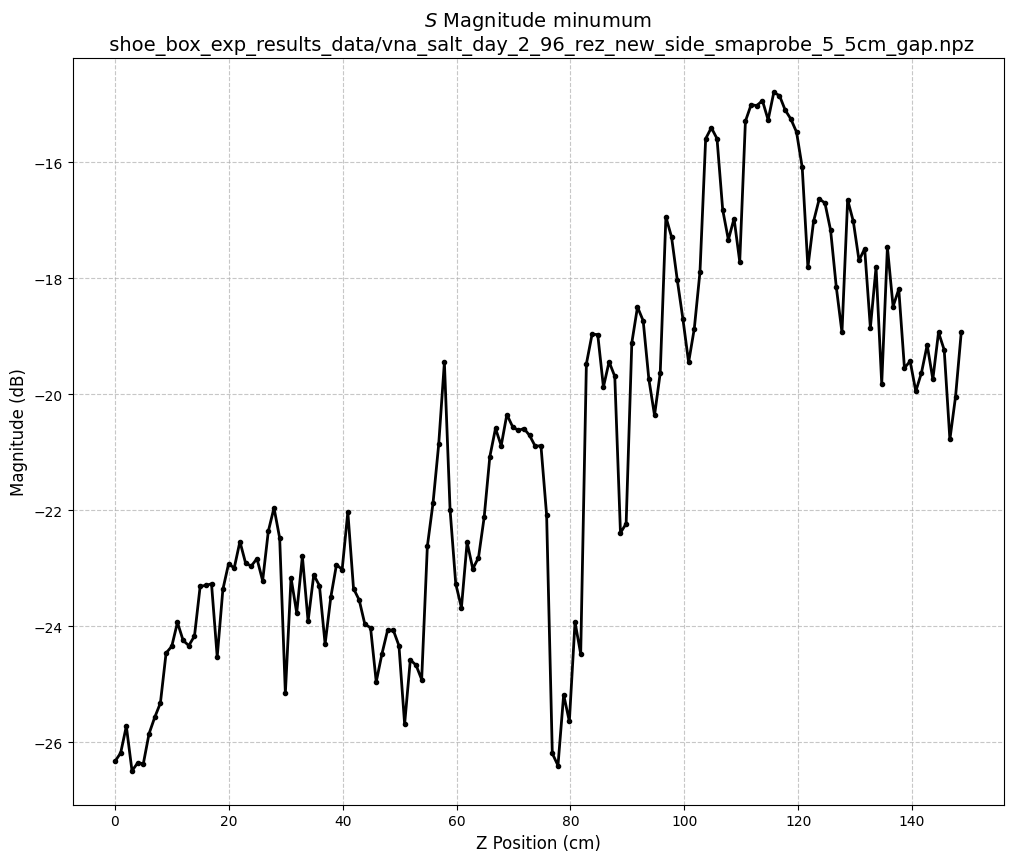

In [119]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))


s11_mag_linear_full = np.abs(S11)
s11_db_full = 20 * np.log10(s11_mag_linear_full)

min_S11_at_positions = np.min(s11_db_full, axis=1)

ax.plot(positions_cm, min_S11_at_positions, color='black', linewidth=2, marker='.')
plt.tight_layout()
ax.set_title(r'$S$ Magnitude minumum' + f'\n {FILENAME}', fontsize=14)
ax.set_xlabel('Z Position (cm)', fontsize=12)
ax.set_ylabel('Magnitude (dB)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [120]:
# pulling from multiple files to show the position scan etc

data_dict = {'2.5': np.load('shoe_box_exp_results_data/vna_salt_day_2_96_rez_noprobe_2_5cm_gap.npz'),
          '3.5': np.load('shoe_box_exp_results_data/vna_salt_day_2_96_rez_noprobe_3_5cm_gap.npz'),
          '4.5': np.load('shoe_box_exp_results_data/vna_salt_day_2_96_rez_noprobe_4_5cm_gap.npz'),
          '5.5': np.load('shoe_box_exp_results_data/vna_salt_day_2_96_rez_noprobe_5_5cm_gap.npz'),
          '6.5': np.load('shoe_box_exp_results_data/vna_salt_day_2_96_rez_noprobe_6_5cm_gap.npz'),
          '7.5': np.load('shoe_box_exp_results_data/vna_salt_day_2_96_rez_noprobe_7_5cm_gap.npz'),
          '8.5': np.load('shoe_box_exp_results_data/vna_salt_day_2_96_rez_noprobe_8_5cm_gap.npz'),
          '9.5': np.load('shoe_box_exp_results_data/vna_salt_day_2_96_rez_noprobe_9_5cm_gap.npz')}

keys = ['2.5', '3.5', '4.5', '5.5', '6.5', '7.5', '8.5', '9.5']

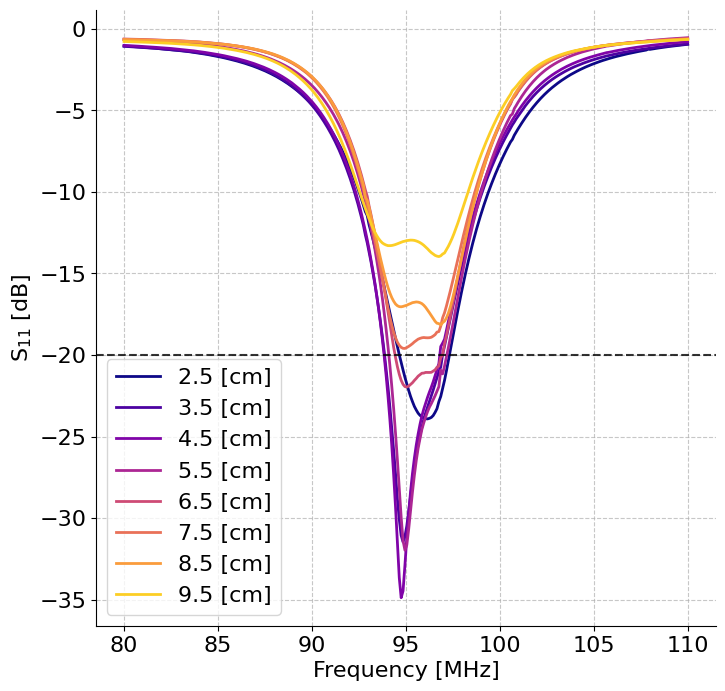

In [121]:
font_size = 16

fig, ax = plt.subplots(1,1,figsize=(8,8))
cmap = plt.colormaps['plasma']
num_colors = len(keys)
colors = cmap(np.linspace(0,.9,num_colors))
i = 0

for key in keys:
    data = data_dict[key]
    freqs_mhz = data['freq [MHz]']
    S11 = data['S11']
    s11_mag_linear = np.abs(S11[0, :])
    s11_db = 20 * np.log10(s11_mag_linear)
    ax.plot(freqs_mhz, s11_db, label=key+' [cm]', linewidth=2, color = colors[i])
    i+=1

ax.set_xlabel('Frequency [MHz]', fontsize=font_size)
ax.set_ylabel(r'S$_{11}$ [dB]', fontsize=font_size)
ax.tick_params(axis='both', labelsize=font_size)
ax.axhline(y=-20, color='black', linestyle='--', alpha=0.8)
ax.legend(fontsize=font_size)
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.axvline(x=93.8)
# ax.axvline(x=97.3)
plt.show()

In [122]:
# now for the fourier specturm plot 
FILENAME = 'shoe_box_exp_results_data/vna_salt_day_2_96_rez_new_side_smaprobe_5_5cm_gap.npz'

# The specific frequency you want to extract the spatial wave from (in MHz)
TARGET_FFT_FREQ_MHZ = 95

clight = 3e8
print(f"Loading {FILENAME}...")
data = np.load(FILENAME)

# Unpack the axes directly from the file!
freqs_mhz = data['freq [MHz]']
positions_cm = data['positions [cm]']

# Unpack the complex S-parameter matrices
S11 = data['S11']
S21 = data['S21']
S31 = data['S31']
S41 = data['S41']

num_measurements = len(positions_cm)

# Dynamically calculate the physical dx step size used in the experiment
dx_real_cm = positions_cm[1] - positions_cm[0]
dx_real_meters = dx_real_cm / 100.0
print(f"Detected spatial step size: {dx_real_cm:.4f} cm")

# Find the column index closest to our target 96 MHz
freq_idx = np.argmin(np.abs(freqs_mhz - TARGET_FFT_FREQ_MHZ))
actual_freq_found = freqs_mhz[freq_idx]
print(f"Extracting spatial data for FFT at {actual_freq_found:.2f} MHz")

max_S41 = 20*np.log10(np.max(np.abs(S41)))
print(f'The maximum S41 is {max_S41} dB')

s41_spatial_wave = S41[:, freq_idx]
#s41_spatial_wave = S41_corrected[:, freq_idx]
# --- THE FIX: Define a highly padded length (must be larger than 160, powers of 2 are fastest) ---
PAD_LENGTH = 2048*2

# Perform the Spatial FFT using the padded length
s41_fft = np.fft.fftshift(np.fft.fft(s41_spatial_wave, n=PAD_LENGTH))
s41_fft_mag = np.abs(s41_fft)

# Calculate the wavenumber (k-space) x-axis using the padded length
k_axis = np.fft.fftshift(np.fft.fftfreq(PAD_LENGTH, d=dx_real_meters)) * 2 * np.pi

# Convert to n-space
n_axis = k_axis * clight / (2 * np.pi * actual_freq_found * 1e6)

Loading shoe_box_exp_results_data/vna_salt_day_2_96_rez_new_side_smaprobe_5_5cm_gap.npz...
Detected spatial step size: 0.9975 cm
Extracting spatial data for FFT at 94.95 MHz
The maximum S41 is -33.27345151614406 dB


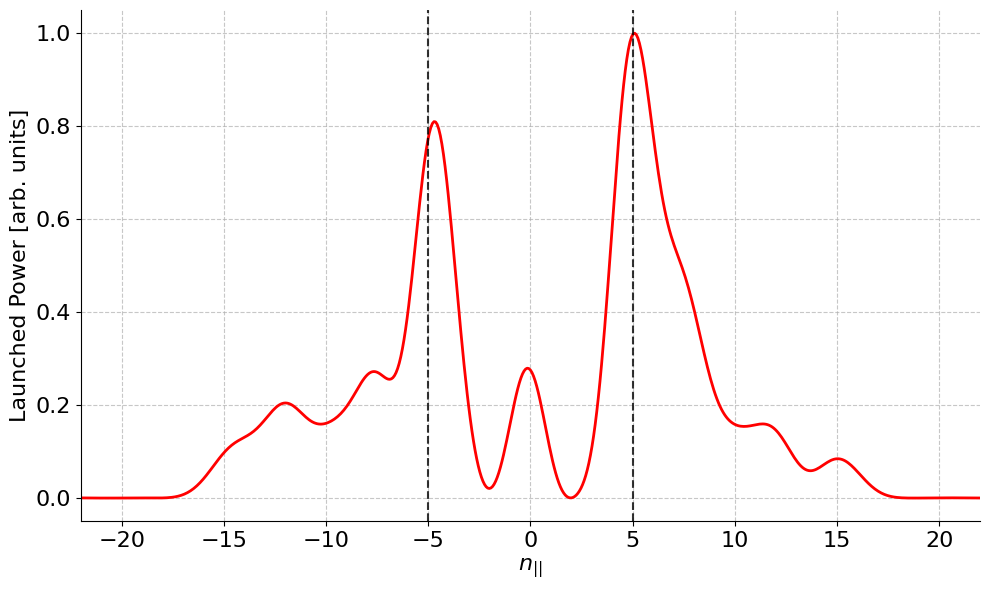

In [123]:
font_size = 16
max_power_spectrum = np.max(s41_fft_mag**2)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(n_axis, s41_fft_mag**2/max_power_spectrum, color='red', linewidth=2)
ax.set_xlabel(r'$n_{||}$', fontsize=font_size)
ax.set_ylabel('Launched Power [arb. units]', fontsize=font_size)
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_xlim(-22, 22)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=font_size)
ax.axvline(x=5, color='black', linestyle='--', alpha=0.8)
ax.axvline(x=-5, color='black', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

The power fraction to coaxial modes is 6.23%
The power fraction to main lobes is 75.48%
The power fraction to electron lobes is 18.29%


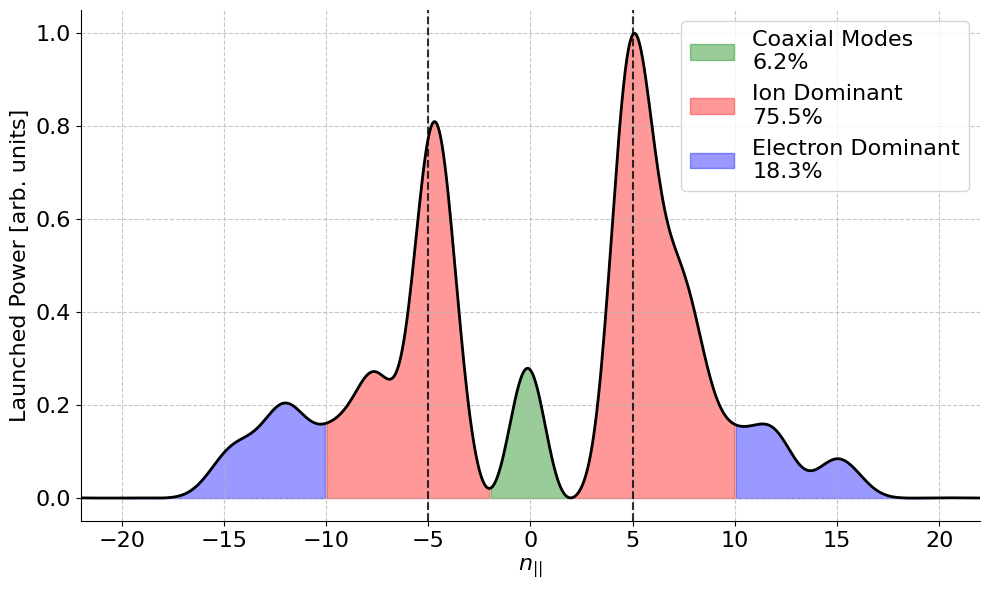

In [124]:
# now make interpolator and take integrals 

spectrum_interp = linear_interp = interp1d(n_axis, s41_fft_mag**2/max_power_spectrum, kind='linear')

def directivity_integral(nmin_global, nmax_global, nmin, nmax, interp, dn):
    # Calculate exactly how many points we need to maintain 'dn' spacing
    num_points_local = int(round((nmax - nmin) / dn)) + 1
    num_points_global = int(round((nmax_global - nmin_global) / dn)) + 1
    
    # Use linspace so the endpoints (nmax and nmax_global) are STRICTLY included
    ns = np.linspace(nmin, nmax, num_points_local)
    ns_global = np.linspace(nmin_global, nmax_global, num_points_global)
    powers = interp(ns)
    powers_global = interp(ns_global)

    int_powers = np.trapz(powers, x=ns)
    int_powers_global = np.trapz(powers_global, x=ns_global)


    area_fraction = int_powers/int_powers_global
    return area_fraction

# fractions

nmin_coaxial = -2
nmax_coaxial = 2

n_ion_cuttoff = 10

# coaxial modes
power_frac_coaxial_modes = directivity_integral(nmin_global=-20,
                                                nmax_global=20,
                                                nmin=nmin_coaxial,
                                                nmax=nmax_coaxial,
                                                interp=spectrum_interp,
                                                dn=0.0001)

# main lobes
power_frac_main_lobes = directivity_integral(nmin_global=-20,
                                                nmax_global=20,
                                                nmin=-n_ion_cuttoff,
                                                nmax=nmin_coaxial,
                                                interp=spectrum_interp,
                                                dn=0.0001) 
power_frac_main_lobes += directivity_integral(nmin_global=-20,
                                                nmax_global=20,
                                                nmin=nmax_coaxial,
                                                nmax=n_ion_cuttoff,
                                                interp=spectrum_interp,
                                                dn=0.0001) 

# electron region 
power_frac_electron = directivity_integral(nmin_global=-20,
                                                nmax_global=20,
                                                nmin=n_ion_cuttoff,
                                                nmax=20,
                                                interp=spectrum_interp,
                                                dn=0.0001) 

power_frac_electron += directivity_integral(nmin_global=-20,
                                                nmax_global=20,
                                                nmin=-20,
                                                nmax=-n_ion_cuttoff,
                                                interp=spectrum_interp,
                                                dn=0.0001) 


print(f'The power fraction to coaxial modes is {power_frac_coaxial_modes*100:.2f}%')
print(f'The power fraction to main lobes is {power_frac_main_lobes*100:.2f}%')
print(f'The power fraction to electron lobes is {power_frac_electron*100:.2f}%')
font_size = 16
max_power_spectrum = np.max(s41_fft_mag**2)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(n_axis, s41_fft_mag**2/max_power_spectrum, color='black', linewidth=2)


# fill between 

# coaxial 
ax.fill_between(n_axis, s41_fft_mag**2/max_power_spectrum, where=(n_axis >= nmin_coaxial) & (n_axis <= nmax_coaxial), 
                 color='green', alpha=0.4, label=f'Coaxial Modes\n{power_frac_coaxial_modes*100:.1f}%')

# main lobes
ax.fill_between(n_axis, s41_fft_mag**2/max_power_spectrum, where=(n_axis >= -n_ion_cuttoff) & (n_axis <= nmin_coaxial), 
                 color='red', alpha=0.4)

ax.fill_between(n_axis, s41_fft_mag**2/max_power_spectrum, where=(n_axis >= nmax_coaxial) & (n_axis <= n_ion_cuttoff), 
                 color='red', alpha=0.4, label=f'Ion Dominant\n{power_frac_main_lobes*100:.1f}%')
# electron
ax.fill_between(n_axis, s41_fft_mag**2/max_power_spectrum, where=(n_axis >= -20) & (n_axis <= -n_ion_cuttoff), 
                 color='blue', alpha=0.4)

ax.fill_between(n_axis, s41_fft_mag**2/max_power_spectrum, where=(n_axis >= n_ion_cuttoff) & (n_axis <= 20), 
                 color='blue', alpha=0.4, label=f'Electron Dominant\n{power_frac_electron*100:.1f}%')

ax.set_xlabel(r'$n_{||}$', fontsize=font_size)
ax.set_ylabel('Launched Power [arb. units]', fontsize=font_size)
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_xlim(-22, 22)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=font_size)
ax.axvline(x=5, color='black', linestyle='--', alpha=0.8)
ax.axvline(x=-5, color='black', linestyle='--', alpha=0.8)
ax.legend(fontsize=font_size)
plt.tight_layout()
plt.show()


In [125]:
# symetric loading figure for 5.5 cm 
# The specific frequency you want to extract the spatial wave from (in MHz)
TARGET_FFT_FREQ_MHZ = 95

print(f"Loading {FILENAME}...")
data = data_dict['5.5']

# Unpack the axes directly from the file!
freqs_mhz = data['freq [MHz]']
positions_cm = data['positions [cm]']

# Unpack the complex S-parameter matrices
S11 = data['S11']
S21 = data['S21']
S31 = data['S31']
S41 = data['S41']

num_measurements = len(positions_cm)

# Dynamically calculate the physical dx step size used in the experiment
dx_real_cm = 1#positions_cm[1] - positions_cm[0]
dx_real_meters = dx_real_cm / 100.0
print(f"Detected spatial step size: {dx_real_cm:.4f} cm")

# Find the column index closest to our target 96 MHz
freq_idx = np.argmin(np.abs(freqs_mhz - TARGET_FFT_FREQ_MHZ))
actual_freq_found = freqs_mhz[freq_idx]
print(f"Extracting spatial data for FFT at {actual_freq_found:.2f} MHz")

max_S41 = 20*np.log10(np.max(np.abs(S41)))
print(f'The maximum S41 is {max_S41} dB')
idx = 0
s11_mag_linear = np.abs(S11[idx, :])
s11_db = 20 * np.log10(s11_mag_linear)

s21_mag_linear = np.abs(S21[idx, :])
s21_db = 20 * np.log10(s21_mag_linear)

s31_mag_linear = np.abs(S31[idx, :])
s31_db = 20 * np.log10(s31_mag_linear)

s41_mag_linear = np.abs(S41[idx, :])
s41_db = 20 * np.log10(s41_mag_linear)

Loading shoe_box_exp_results_data/vna_salt_day_2_96_rez_new_side_smaprobe_5_5cm_gap.npz...
Detected spatial step size: 1.0000 cm
Extracting spatial data for FFT at 94.95 MHz
The maximum S41 is -67.56438960406017 dB


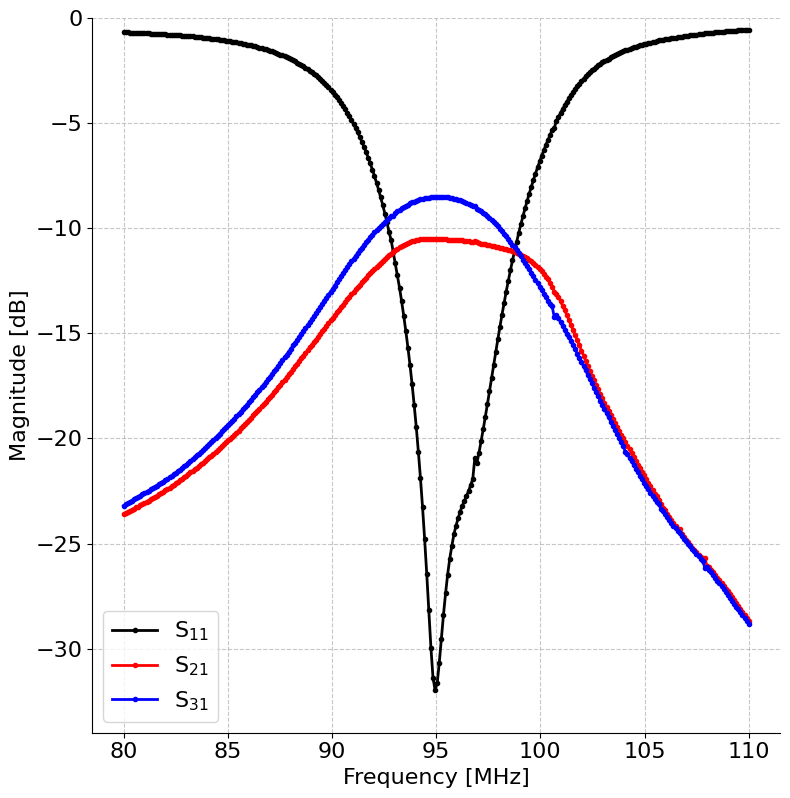

In [126]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

fontsize=16
# --- Plot 1: S11, s21, S31 vs Frequency ---
ax.plot(freqs_mhz, s11_db, color='black', marker='.', linewidth=2, label=r'S$_{11}$')
ax.plot(freqs_mhz, s21_db, color='red', marker='.', linewidth=2, label=r'S$_{21}$')
ax.plot(freqs_mhz, s31_db, color='blue', marker='.', linewidth=2, label=r'S$_{31}$')
ax.set_xlabel('Frequency [MHz]', fontsize=font_size)
ax.set_ylabel('Magnitude [dB]', fontsize=font_size)
ax.tick_params(axis='both', labelsize=font_size)
#ax.axvline(TARGET_FFT_FREQ_MHZ, color='red', linestyle='--', label=f'Target: {TARGET_FFT_FREQ_MHZ:.1f} MHz')
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.legend(fontsize=font_size)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
ax.set_ylim(-34, 0)
plt.show()

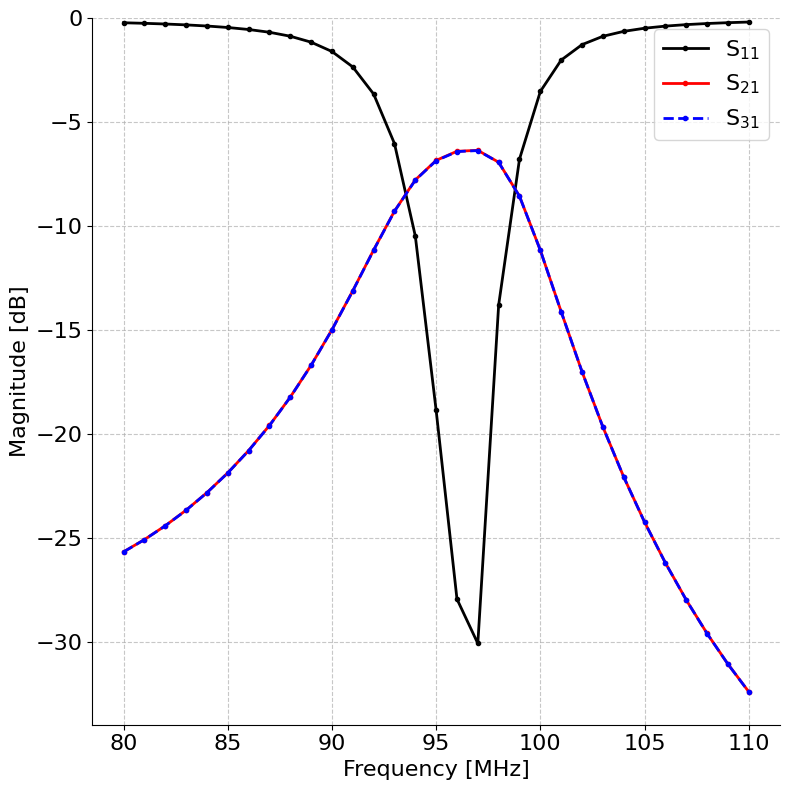

In [127]:
# comsol results 

file_name = 'S_param_plot.csv'
sparam_comsol_data = np.loadtxt(file_name, delimiter=',', skiprows=8)
block1, block2, block3 = np.split(sparam_comsol_data, 3)

# 3. Extract the columns for each S-parameter
# They all share the same frequency x-axis, so we only need 'x' once
freq = block1[:, 0]  

s11 = block1[:, 1]
s21 = block2[:, 1]
s31 = block3[:, 1]
font_size = 16

fig, ax = plt.subplots(1,1,figsize=(8,8))

ax.plot(freq, s11, color='black', marker='.', linewidth=2, label=r'S$_{11}$')
ax.plot(freq, s21, color='red', marker='.', linewidth=2, label=r'S$_{21}$')
ax.plot(freq, s31, color='blue', marker='.', linestyle='--', linewidth=2, label=r'S$_{31}$')

ax.set_xlabel('Frequency [MHz]', fontsize=font_size)
ax.set_ylabel('Magnitude [dB]', fontsize=font_size)
ax.tick_params(axis='both', labelsize=font_size)
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.legend(fontsize=font_size)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(-34, 0)
plt.tight_layout()
plt.show()

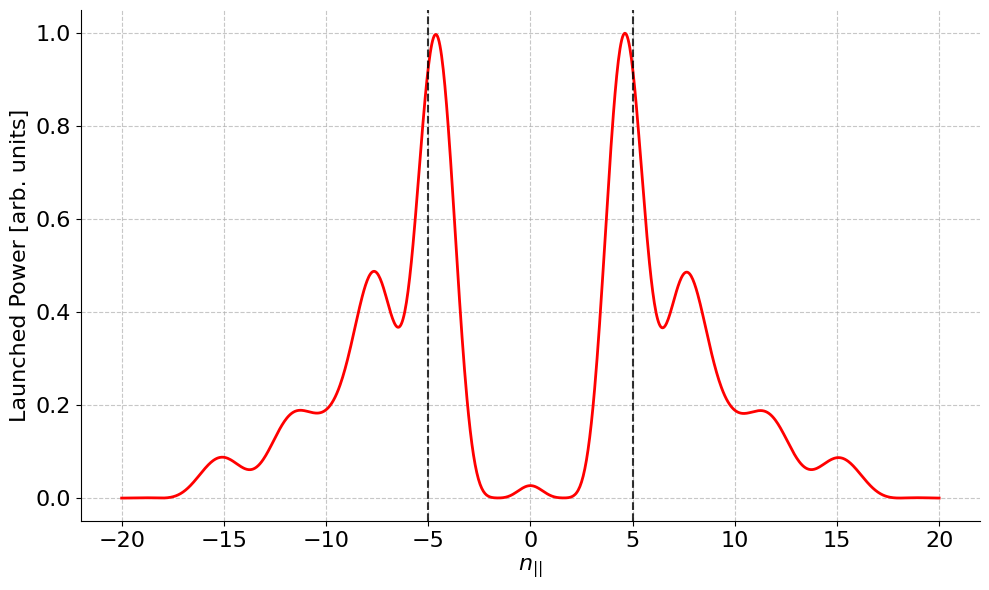

In [128]:
# comsol spectrum 

file_name = 'npar_spectrum_plot.csv'
sparam_comsol_data = np.loadtxt(file_name, delimiter=',', skiprows=8)
npar = sparam_comsol_data[:,0]
power = sparam_comsol_data[:,1]

font_size = 16
max_power_spectrum = np.max(s41_fft_mag**2)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(npar, power/np.max(power), color='red', linewidth=2)
ax.set_xlabel(r'$n_{||}$', fontsize=font_size)
ax.set_ylabel('Launched Power [arb. units]', fontsize=font_size)
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_xlim(-22, 22)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=font_size)
ax.axvline(x=5, color='black', linestyle='--', alpha=0.8)
ax.axvline(x=-5, color='black', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

In [129]:
# old probe spectrum 
# now for the fourier specturm plot 
FILENAME = 'shoe_box_exp_results_data/vna_salt_day_1_96_rez_manual1_5_5cm_gap.npz'

# The specific frequency you want to extract the spatial wave from (in MHz)
TARGET_FFT_FREQ_MHZ = 95

clight = 3e8
print(f"Loading {FILENAME}...")
data = np.load(FILENAME)

# Unpack the axes directly from the file!
freqs_mhz = data['freq [MHz]']
positions_cm = data['positions [cm]']

# Unpack the complex S-parameter matrices
S11 = data['S11']
S21 = data['S21']
S31 = data['S31']
S41 = data['S41']

num_measurements = len(positions_cm)

# Dynamically calculate the physical dx step size used in the experiment
dx_real_cm = positions_cm[1] - positions_cm[0]
dx_real_meters = dx_real_cm / 100.0
print(f"Detected spatial step size: {dx_real_cm:.4f} cm")

# Find the column index closest to our target 96 MHz
freq_idx = np.argmin(np.abs(freqs_mhz - TARGET_FFT_FREQ_MHZ))
actual_freq_found = freqs_mhz[freq_idx]
print(f"Extracting spatial data for FFT at {actual_freq_found:.2f} MHz")

max_S41 = 20*np.log10(np.max(np.abs(S41)))
print(f'The maximum S41 is {max_S41} dB')

s41_spatial_wave = S41[:, freq_idx]
#s41_spatial_wave = S41_corrected[:, freq_idx]
# --- THE FIX: Define a highly padded length (must be larger than 160, powers of 2 are fastest) ---
PAD_LENGTH = 2048*2

# Perform the Spatial FFT using the padded length
s41_fft = np.fft.fftshift(np.fft.fft(s41_spatial_wave, n=PAD_LENGTH))
s41_fft_mag = np.abs(s41_fft)

# Calculate the wavenumber (k-space) x-axis using the padded length
k_axis = np.fft.fftshift(np.fft.fftfreq(PAD_LENGTH, d=dx_real_meters)) * 2 * np.pi

# Convert to n-space
n_axis = k_axis * clight / (2 * np.pi * actual_freq_found * 1e6)

Loading shoe_box_exp_results_data/vna_salt_day_1_96_rez_manual1_5_5cm_gap.npz...
Detected spatial step size: 0.9975 cm
Extracting spatial data for FFT at 94.95 MHz
The maximum S41 is -36.5088226361515 dB


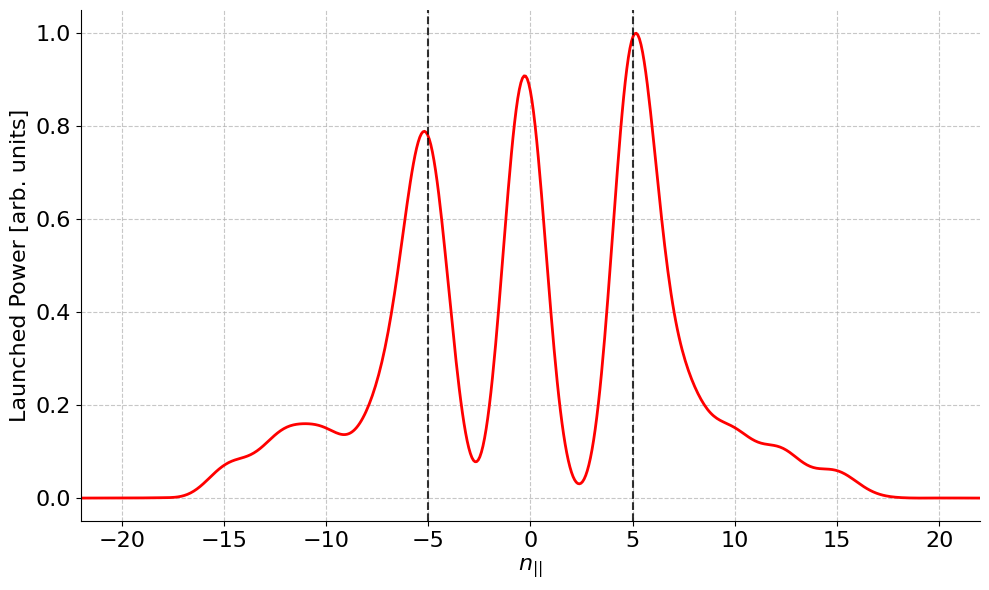

In [130]:
font_size = 16
max_power_spectrum = np.max(s41_fft_mag**2)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(n_axis, s41_fft_mag**2/max_power_spectrum, color='red', linewidth=2)
ax.set_xlabel(r'$n_{||}$', fontsize=font_size)
ax.set_ylabel('Launched Power [arb. units]', fontsize=font_size)
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_xlim(-22, 22)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=font_size)
ax.axvline(x=5, color='black', linestyle='--', alpha=0.8)
ax.axvline(x=-5, color='black', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

Loading shoe_box_exp_results_data/vna_salt_day_2_96_rez_probe_expm1_5_5cm_gap.npz...
Detected spatial step size: 0.9975 cm
Extracting spatial data for FFT at 94.95 MHz
The maximum S41 is -26.628677754348352 dB


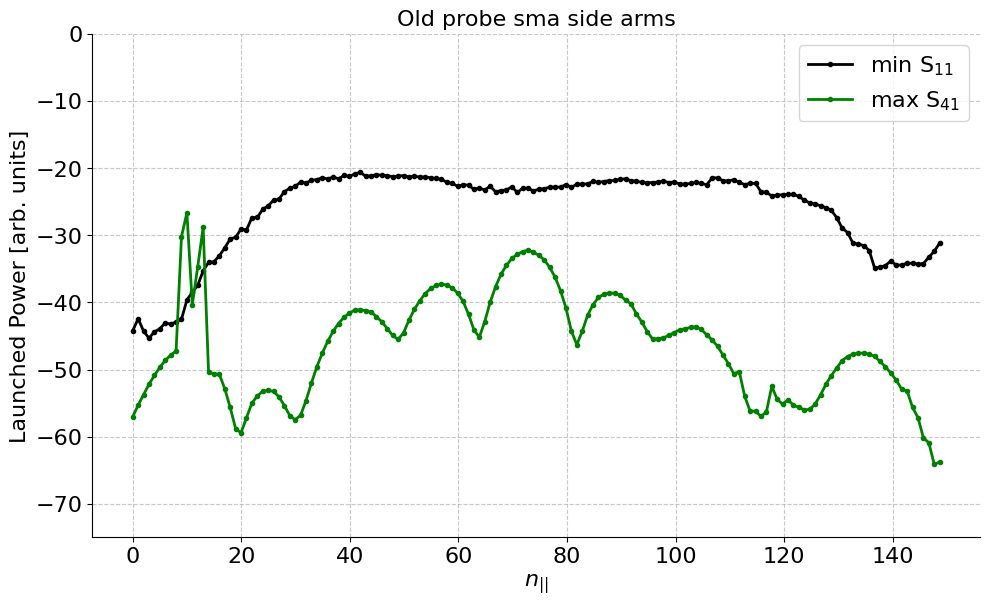

In [131]:
# plots of the probe's effect on things 
FILENAME = 'shoe_box_exp_results_data/vna_salt_day_2_96_rez_probe_expm1_5_5cm_gap.npz'

# The specific frequency you want to extract the spatial wave from (in MHz)
TARGET_FFT_FREQ_MHZ = 95

clight = 3e8

# ==========================================
# 2. DYNAMIC DATA UNPACKING
# ==========================================
print(f"Loading {FILENAME}...")
data = np.load(FILENAME)

# Unpack the axes directly from the file!
freqs_mhz = data['freq [MHz]']
positions_cm = data['positions [cm]']

# Unpack the complex S-parameter matrices
S11 = data['S11']
S21 = data['S21']
S31 = data['S31']
S41 = data['S41']

num_measurements = len(positions_cm)

# Dynamically calculate the physical dx step size used in the experiment
dx_real_cm = positions_cm[1] - positions_cm[0]
dx_real_meters = dx_real_cm / 100.0
print(f"Detected spatial step size: {dx_real_cm:.4f} cm")

# Find the column index closest to our target 96 MHz
freq_idx = np.argmin(np.abs(freqs_mhz - TARGET_FFT_FREQ_MHZ))
actual_freq_found = freqs_mhz[freq_idx]
print(f"Extracting spatial data for FFT at {actual_freq_found:.2f} MHz")

max_S41 = 20*np.log10(np.max(np.abs(S41)))
print(f'The maximum S41 is {max_S41} dB')

# extract the data 

s11_mag_linear_full = np.abs(S11)
s11_db_full = 20 * np.log10(s11_mag_linear_full)

min_S11_at_positions = np.min(s11_db_full, axis=1)

s41_mag_linear_full = np.abs(S41)
s41_db_full = 20 * np.log10(s41_mag_linear_full)

max_S41_at_positions = np.max(s41_db_full, axis=1)

font_size = 16
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(positions_cm, min_S11_at_positions, color='black', linewidth=2, marker='.', label=r'min S$_{11}$')
ax.plot(positions_cm, max_S41_at_positions, color='GREEN', linewidth=2, marker='.', label=r'max S$_{41}$')
ax.set_xlabel(r'$n_{||}$', fontsize=font_size)
ax.set_ylabel('Launched Power [arb. units]', fontsize=font_size)
ax.grid(True, linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=font_size)
ax.legend(fontsize=font_size)
ax.set_ylim(-75, 0)
plt.tight_layout()
ax.set_title('Old probe sma side arms', fontsize=fontsize)
plt.show()

Loading shoe_box_exp_results_data/vna_salt_day_2_96_rez_new_side_smaprobe_5_5cm_gap.npz...
Detected spatial step size: 0.9975 cm
Extracting spatial data for FFT at 94.95 MHz
The maximum S41 is -33.27345151614406 dB


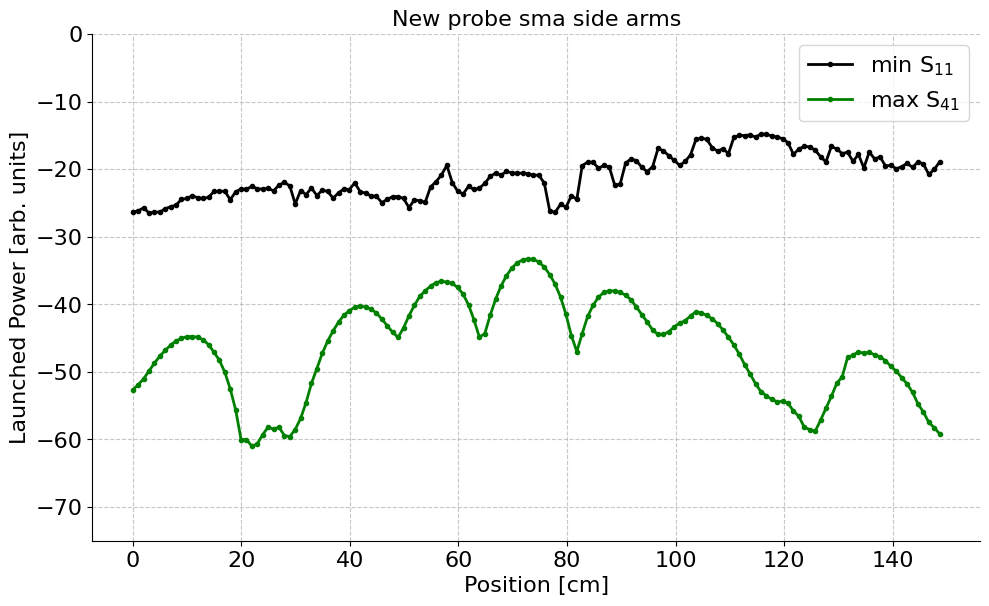

In [132]:
# plots of the probe's effect on things 
FILENAME = 'shoe_box_exp_results_data/vna_salt_day_2_96_rez_new_side_smaprobe_5_5cm_gap.npz'

# The specific frequency you want to extract the spatial wave from (in MHz)
TARGET_FFT_FREQ_MHZ = 95

clight = 3e8

# ==========================================
# 2. DYNAMIC DATA UNPACKING
# ==========================================
print(f"Loading {FILENAME}...")
data = np.load(FILENAME)

# Unpack the axes directly from the file!
freqs_mhz = data['freq [MHz]']
positions_cm = data['positions [cm]']

# Unpack the complex S-parameter matrices
S11 = data['S11']
S21 = data['S21']
S31 = data['S31']
S41 = data['S41']

num_measurements = len(positions_cm)

# Dynamically calculate the physical dx step size used in the experiment
dx_real_cm = positions_cm[1] - positions_cm[0]
dx_real_meters = dx_real_cm / 100.0
print(f"Detected spatial step size: {dx_real_cm:.4f} cm")

# Find the column index closest to our target 96 MHz
freq_idx = np.argmin(np.abs(freqs_mhz - TARGET_FFT_FREQ_MHZ))
actual_freq_found = freqs_mhz[freq_idx]
print(f"Extracting spatial data for FFT at {actual_freq_found:.2f} MHz")

max_S41 = 20*np.log10(np.max(np.abs(S41)))
print(f'The maximum S41 is {max_S41} dB')

# extract the data 

s11_mag_linear_full = np.abs(S11)
s11_db_full = 20 * np.log10(s11_mag_linear_full)

min_S11_at_positions = np.min(s11_db_full, axis=1)

s41_mag_linear_full = np.abs(S41)
s41_db_full = 20 * np.log10(s41_mag_linear_full)

max_S41_at_positions = np.max(s41_db_full, axis=1)

font_size = 16
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(positions_cm, min_S11_at_positions, color='black', linewidth=2, marker='.', label=r'min S$_{11}$')
ax.plot(positions_cm, max_S41_at_positions, color='GREEN', linewidth=2, marker='.', label=r'max S$_{41}$')
ax.set_xlabel('Position [cm]', fontsize=font_size)
ax.set_ylabel('Launched Power [arb. units]', fontsize=font_size)
ax.grid(True, linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=font_size)
ax.legend(fontsize=font_size)
ax.set_ylim(-75, 0)
plt.tight_layout()
ax.set_title('New probe sma side arms', fontsize=fontsize)
plt.show()

Loading shoe_box_exp_results_data/vna_salt_day_2_96_rez_no_side_smaprobe_5_5cm_gap.npz...
Detected spatial step size: 0.9975 cm
Extracting spatial data for FFT at 94.95 MHz
The maximum S41 is -68.88955372393212 dB


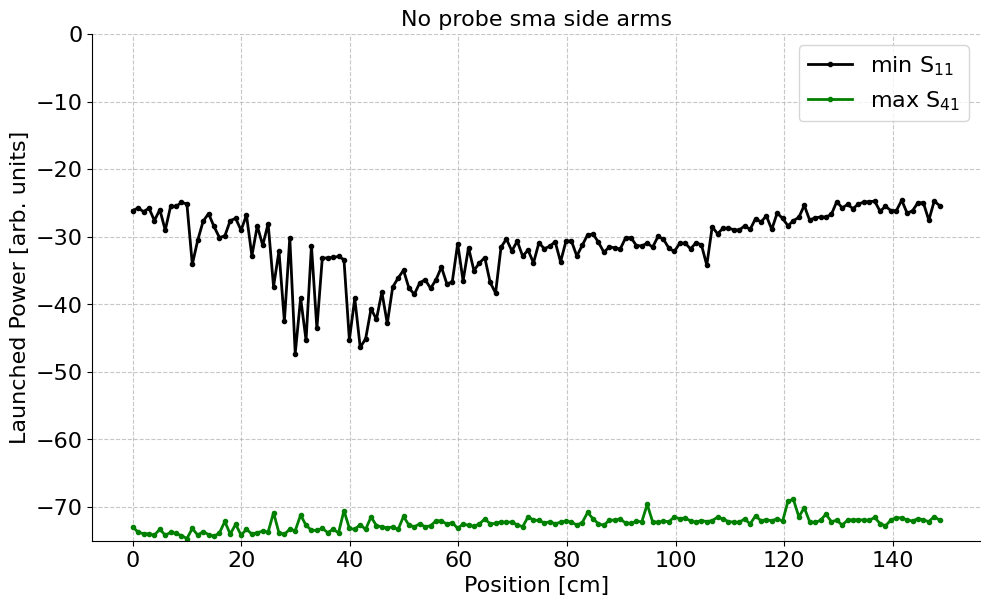

In [133]:
# plots of the probe's effect on things 
FILENAME = 'shoe_box_exp_results_data/vna_salt_day_2_96_rez_no_side_smaprobe_5_5cm_gap.npz'

# The specific frequency you want to extract the spatial wave from (in MHz)
TARGET_FFT_FREQ_MHZ = 95

clight = 3e8

# ==========================================
# 2. DYNAMIC DATA UNPACKING
# ==========================================
print(f"Loading {FILENAME}...")
data = np.load(FILENAME)

# Unpack the axes directly from the file!
freqs_mhz = data['freq [MHz]']
positions_cm = data['positions [cm]']

# Unpack the complex S-parameter matrices
S11 = data['S11']
S21 = data['S21']
S31 = data['S31']
S41 = data['S41']

num_measurements = len(positions_cm)

# Dynamically calculate the physical dx step size used in the experiment
dx_real_cm = positions_cm[1] - positions_cm[0]
dx_real_meters = dx_real_cm / 100.0
print(f"Detected spatial step size: {dx_real_cm:.4f} cm")

# Find the column index closest to our target 96 MHz
freq_idx = np.argmin(np.abs(freqs_mhz - TARGET_FFT_FREQ_MHZ))
actual_freq_found = freqs_mhz[freq_idx]
print(f"Extracting spatial data for FFT at {actual_freq_found:.2f} MHz")

max_S41 = 20*np.log10(np.max(np.abs(S41)))
print(f'The maximum S41 is {max_S41} dB')

# extract the data 

s11_mag_linear_full = np.abs(S11)
s11_db_full = 20 * np.log10(s11_mag_linear_full)

min_S11_at_positions = np.min(s11_db_full, axis=1)

s41_mag_linear_full = np.abs(S41)
s41_db_full = 20 * np.log10(s41_mag_linear_full)

max_S41_at_positions = np.max(s41_db_full, axis=1)

font_size = 16
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(positions_cm, min_S11_at_positions, color='black', linewidth=2, marker='.', label=r'min S$_{11}$')
ax.plot(positions_cm, max_S41_at_positions, color='GREEN', linewidth=2, marker='.', label=r'max S$_{41}$')
ax.set_xlabel('Position [cm]', fontsize=font_size)
ax.set_ylabel('Launched Power [arb. units]', fontsize=font_size)
ax.grid(True, linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=font_size)
ax.legend(fontsize=font_size)
ax.set_ylim(-75, 0)
plt.tight_layout()
ax.set_title('No probe sma side arms', fontsize=fontsize)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Loading shoe_box_exp_results_data/vna_salt_day_3_94_rez_new_side_smaprobe_edgefields_5_5cm_gap.npz...
Detected spatial step size: 0.9975 cm
Extracting spatial data for FFT at 94.55 MHz
The maximum S41 is -33.86442178478807 dB


C:\Users\jacob\AppData\Local\Temp\ipykernel_45944\1880137794.py:130: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


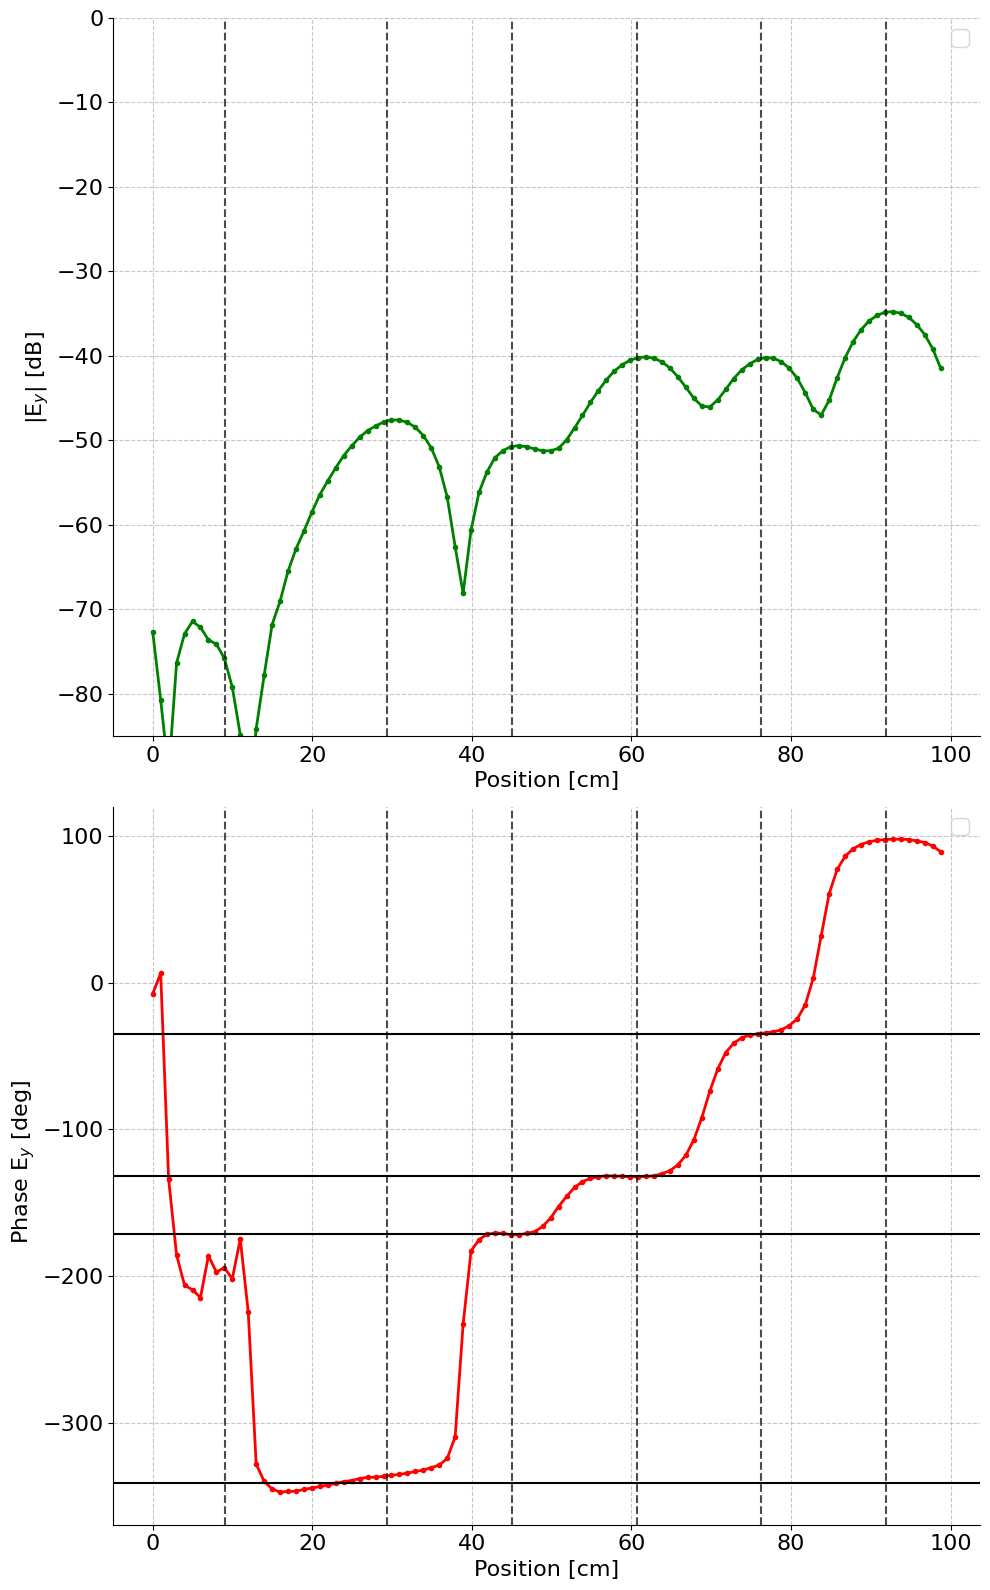

In [164]:
# side expand probe measurments 
# plots of the probe's effect on things 
FILENAME = 'shoe_box_exp_results_data/vna_salt_day_3_94_rez_new_side_smaprobe_edgefields_5_5cm_gap.npz'

# The specific frequency you want to extract the spatial wave from (in MHz)
TARGET_FFT_FREQ_MHZ = 94.5

clight = 3e8

# ==========================================
# 2. DYNAMIC DATA UNPACKING
# ==========================================
print(f"Loading {FILENAME}...")
data = np.load(FILENAME)

# Unpack the axes directly from the file!
freqs_mhz = data['freq [MHz]']
positions_cm = data['positions [cm]']

# Unpack the complex S-parameter matrices
S11 = data['S11']
S21 = data['S21']
S31 = data['S31']
S41 = data['S41']

num_measurements = len(positions_cm)

# Dynamically calculate the physical dx step size used in the experiment
dx_real_cm = positions_cm[1] - positions_cm[0]
dx_real_meters = dx_real_cm / 100.0
print(f"Detected spatial step size: {dx_real_cm:.4f} cm")

# Find the column index closest to our target 96 MHz
freq_idx = np.argmin(np.abs(freqs_mhz - TARGET_FFT_FREQ_MHZ))
actual_freq_found = freqs_mhz[freq_idx]
print(f"Extracting spatial data for FFT at {actual_freq_found:.2f} MHz")

max_S41 = 20*np.log10(np.max(np.abs(S41)))
print(f'The maximum S41 is {max_S41} dB')

# extract the data 
idx = 0
s11_mag_linear = np.abs(S11[idx, :])
s11_db = 20 * np.log10(s11_mag_linear)

s21_mag_linear = np.abs(S21[idx, :])
s21_db = 20 * np.log10(s21_mag_linear)

s31_mag_linear = np.abs(S31[idx, :])
s31_db = 20 * np.log10(s31_mag_linear)

s41_mag_linear = np.abs(S41[idx, :])
s41_db = 20 * np.log10(s41_mag_linear)

s11_mag_linear_full = np.abs(S11)
s11_db_full = 20 * np.log10(s11_mag_linear_full)

min_S11_at_positions = np.min(s11_db_full, axis=1)

s41_mag_linear_full = np.abs(S41)
s41_db_full = 20 * np.log10(s41_mag_linear_full)
s41_spatial_wave_mag = 20*np.log10(np.abs(S41[:, freq_idx]))
s41_spatial_wave_phase = np.angle(S41[:, freq_idx])
unwrapped_phase = np.unwrap(s41_spatial_wave_phase)
phase_diff = np.diff(unwrapped_phase)

max_S41_at_positions = np.max(s41_db_full, axis=1)

font_size = 16
fig, ax = plt.subplots(2, 1, figsize=(10, 16))

offset = 9.1
end_to_first_strap = 16.32+4
sep = 15.625

strap_positions = np.array([0,
                            end_to_first_strap,
                            end_to_first_strap + sep,
                            end_to_first_strap + 2*sep,
                            end_to_first_strap + 3*sep,
                            end_to_first_strap + 4*sep]) + offset

#ax.plot(positions_cm, min_S11_at_positions, color='black', linewidth=2, marker='.', label=r'min S$_{11}$')
ax[0].plot(positions_cm, s41_spatial_wave_mag, color='GREEN', linewidth=2, marker='.')
ax[0].set_xlabel('Position [cm]', fontsize=font_size)
ax[0].set_ylabel(r'|E$_y$| [dB]', fontsize=font_size)
ax[0].grid(True, linestyle='--', alpha=0.7)

for pos in strap_positions:
    ax[0].axvline(x=pos, color='black', linestyle='--', alpha=0.7)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].tick_params(axis='both', labelsize=font_size)
ax[0].legend(fontsize=font_size)
ax[0].set_ylim(-85, 0)
plt.tight_layout()


# ax[1].plot(positions_cm[:-1], phase_diff*180/np.pi, color='blue', linewidth=2, marker='.')
# ax[1].set_xlabel('Position [cm]', fontsize=font_size)
# ax[1].set_ylabel(r'$\Delta$ Phase(E$_y$) [deg]', fontsize=font_size)
# ax[1].grid(True, linestyle='--', alpha=0.7)

# for pos in strap_positions:
#     ax[1].axvline(x=pos, color='black', linestyle='--', alpha=0.7)
# ax[1].spines['top'].set_visible(False)
# ax[1].spines['right'].set_visible(False)
# ax[1].tick_params(axis='both', labelsize=font_size)
# ax[1].legend(fontsize=font_size)
# ax[1].set_ylim(-10, 90)


ax[1].plot(positions_cm, unwrapped_phase*180/np.pi, color='red', linewidth=2, marker='.')
ax[1].set_xlabel('Position [cm]', fontsize=font_size)
ax[1].set_ylabel(r' Phase E$_y$ [deg]', fontsize=font_size)
ax[1].grid(True, linestyle='--', alpha=0.7)

for pos in strap_positions:
    ax[1].axvline(x=pos, color='black', linestyle='--', alpha=0.7)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].tick_params(axis='both', labelsize=font_size)
ax[1].legend(fontsize=font_size)

ax[1].axhline(y=-35,color='black')
ax[1].axhline(y=-132,color='black')
ax[1].axhline(y=-171,color='black')
ax[1].axhline(y=-341,color='black')

plt.tight_layout()
# ax[1].axhline(y=180, color='black', linestyle='--', alpha=0.7)
# ax[1].axhline(y=-180, color='black', linestyle='--', alpha=0.7)
plt.show()


In [135]:
# phase plot 



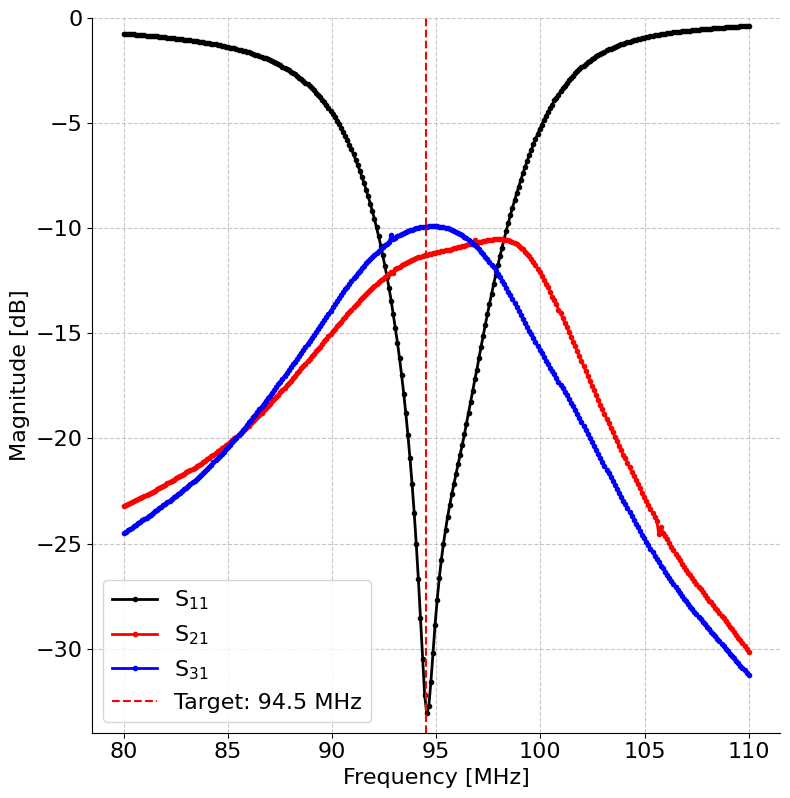

In [136]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

fontsize=16
# --- Plot 1: S11, s21, S31 vs Frequency ---
ax.plot(freqs_mhz, s11_db, color='black', marker='.', linewidth=2, label=r'S$_{11}$')
ax.plot(freqs_mhz, s21_db, color='red', marker='.', linewidth=2, label=r'S$_{21}$')
ax.plot(freqs_mhz, s31_db, color='blue', marker='.', linewidth=2, label=r'S$_{31}$')
ax.set_xlabel('Frequency [MHz]', fontsize=font_size)
ax.set_ylabel('Magnitude [dB]', fontsize=font_size)
ax.tick_params(axis='both', labelsize=font_size)
ax.axvline(TARGET_FFT_FREQ_MHZ, color='red', linestyle='--', label=f'Target: {TARGET_FFT_FREQ_MHZ:.1f} MHz')
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.legend(fontsize=font_size)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
ax.set_ylim(-34, 0)
plt.show()